In [7]:
# %%
# nn.py

In [8]:
# %%
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import neural_network
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA, FastICA
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.random_projection import GaussianRandomProjection
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
os.makedirs("./result", exist_ok=True)


In [9]:
# %%
# Load the Breast Cancer dataset
bc_data = load_breast_cancer()
X = bc_data.data
y = bc_data.target

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode the target
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1, 1))

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
# %%
# Apply dimensionality reduction techniques
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

ica = FastICA(n_components=2, random_state=42)
X_train_ica = ica.fit_transform(X_train)
X_test_ica = ica.transform(X_test)

rp = GaussianRandomProjection(n_components=2, random_state=42)
X_train_rp = rp.fit_transform(X_train)
X_test_rp = rp.transform(X_test)


In [11]:
# %%
# Train a neural network classifier
NeuralNetwork = neural_network.MLPClassifier(max_iter=3000, random_state=42)
param_grid = {
    "hidden_layer_sizes": np.arange(2, 50, 2),
    "activation": ["logistic", "relu", "tanh"],
    "solver": ["adam", "sgd"],
    "alpha": [0.001, 0.01, 0.1],
    "learning_rate": ["invscaling", "adaptive"],
    "learning_rate_init": [0.001, 0.01, 0.1],
}


def fit_and_evaluate(X_train, X_test, y_train, y_test, method_name):
    NeuralNetworkCV = GridSearchCV(
        NeuralNetwork, param_grid, cv=5, n_jobs=-1, verbose=0
    )
    
    start_time = time.time()
    NeuralNetworkCV.fit(X_train, y_train)
    end_time = time.time()
    
    training_time = end_time - start_time
    print(f"Training time ({method_name}): {training_time:.2f} seconds")
    print(f"Best parameters ({method_name}): {NeuralNetworkCV.best_params_}")

    y_train_pred = NeuralNetworkCV.predict(X_train)
    y_test_pred = NeuralNetworkCV.predict(X_test)
    
    train_score = NeuralNetworkCV.score(X_train, y_train)
    test_score = NeuralNetworkCV.score(X_test, y_test)
    print(f"Train accuracy ({method_name}): {train_score:.4f}")
    print(f"Test accuracy ({method_name}): {test_score:.4f}")

    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_test_pred, average='weighted')

    print(f"Precision ({method_name}): {precision:.4f}")
    print(f"Recall ({method_name}): {recall:.4f}")
    print(f"F1 Score ({method_name}): {f1:.4f}")
    print(f"ROC AUC Score ({method_name}): {roc_auc:.4f}")

    cm = confusion_matrix(y_test.argmax(axis=1), y_test_pred.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='viridis')
    plt.title(f"Confusion Matrix ({method_name})")
    plt.savefig(f"./result/confusion_matrix_{method_name.lower()}.png")
    plt.show()

    BestNeuralNetwork = NeuralNetworkCV.best_estimator_
    train_sizes, train_scores, test_scores = learning_curve(
        BestNeuralNetwork,
        X_train,
        y_train,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 20),
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(12, 8))
    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="b",
    )
    plt.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="r",
    )
    plt.plot(train_sizes, train_scores_mean, "o-", color="b", label="Training score")
    plt.plot(
        train_sizes, test_scores_mean, "o-", color="r", label="Cross-validation score"
    )
    plt.title(f"Learning Curve ({method_name})")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.savefig(f"./result/learning_curve_{method_name.lower()}.png")
    plt.show()

    return NeuralNetworkCV.best_estimator_, train_score, test_score, training_time, precision, recall, f1, roc_auc



Training time (Original): 532.83 seconds
Best parameters (Original): {'activation': 'logistic', 'alpha': 0.1, 'hidden_layer_sizes': np.int64(42), 'learning_rate': 'invscaling', 'learning_rate_init': 0.1, 'solver': 'adam'}
Train accuracy (Original): 0.9824
Test accuracy (Original): 0.9912
Precision (Original): 0.9913
Recall (Original): 0.9912
F1 Score (Original): 0.9912
ROC AUC Score (Original): 0.9884


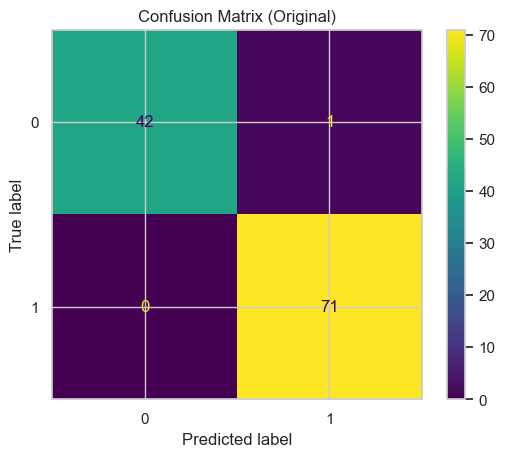

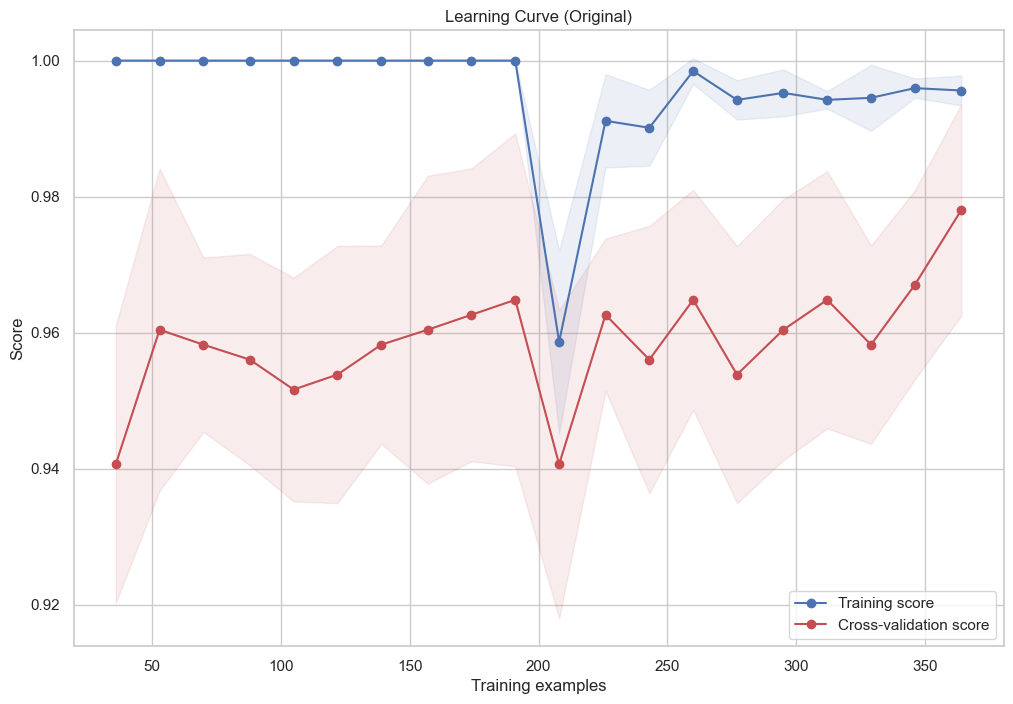

Training time (PCA): 381.40 seconds
Best parameters (PCA): {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': np.int64(2), 'learning_rate': 'invscaling', 'learning_rate_init': 0.01, 'solver': 'adam'}
Train accuracy (PCA): 0.9473
Test accuracy (PCA): 0.9912
Precision (PCA): 0.9913
Recall (PCA): 0.9912
F1 Score (PCA): 0.9912
ROC AUC Score (PCA): 0.9884


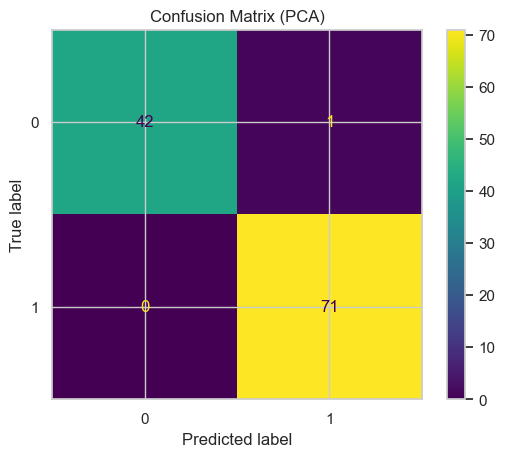

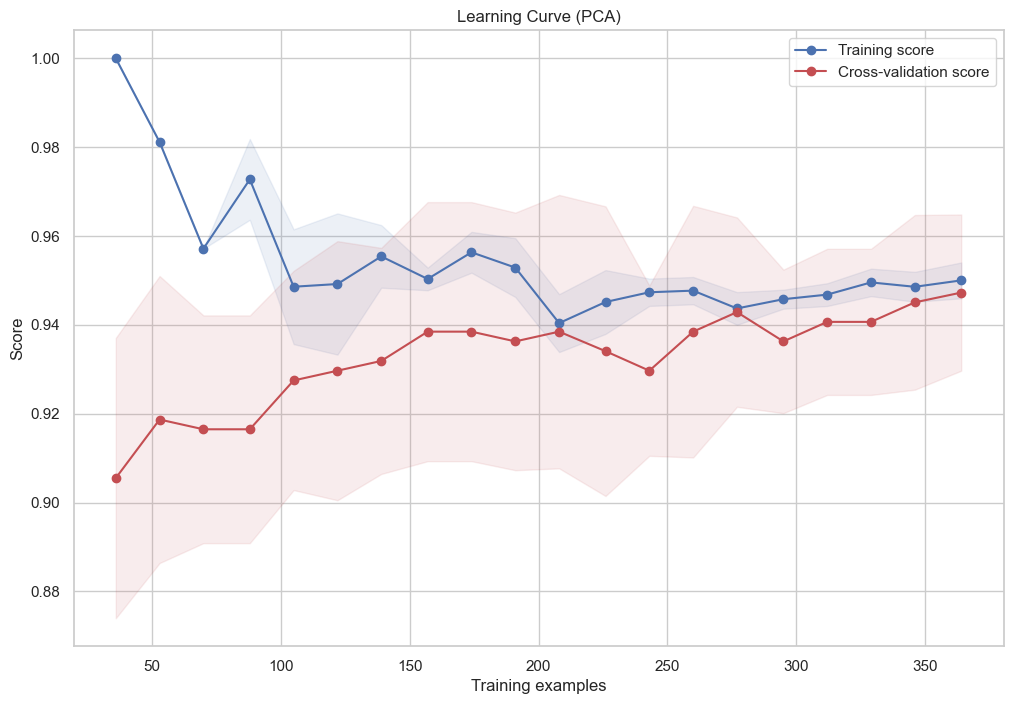

Training time (ICA): 449.45 seconds
Best parameters (ICA): {'activation': 'logistic', 'alpha': 0.001, 'hidden_layer_sizes': np.int64(14), 'learning_rate': 'invscaling', 'learning_rate_init': 0.1, 'solver': 'adam'}
Train accuracy (ICA): 0.9495
Test accuracy (ICA): 0.9912
Precision (ICA): 0.9913
Recall (ICA): 0.9912
F1 Score (ICA): 0.9912
ROC AUC Score (ICA): 0.9884


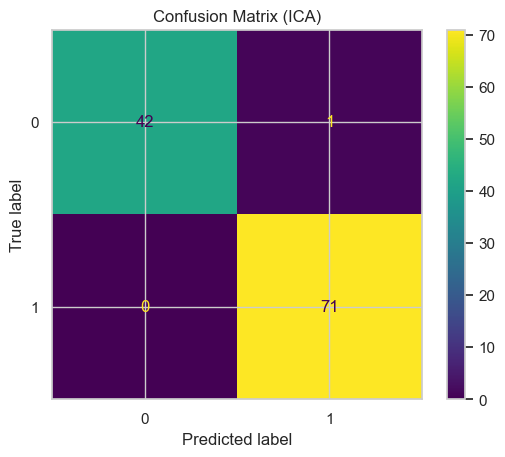

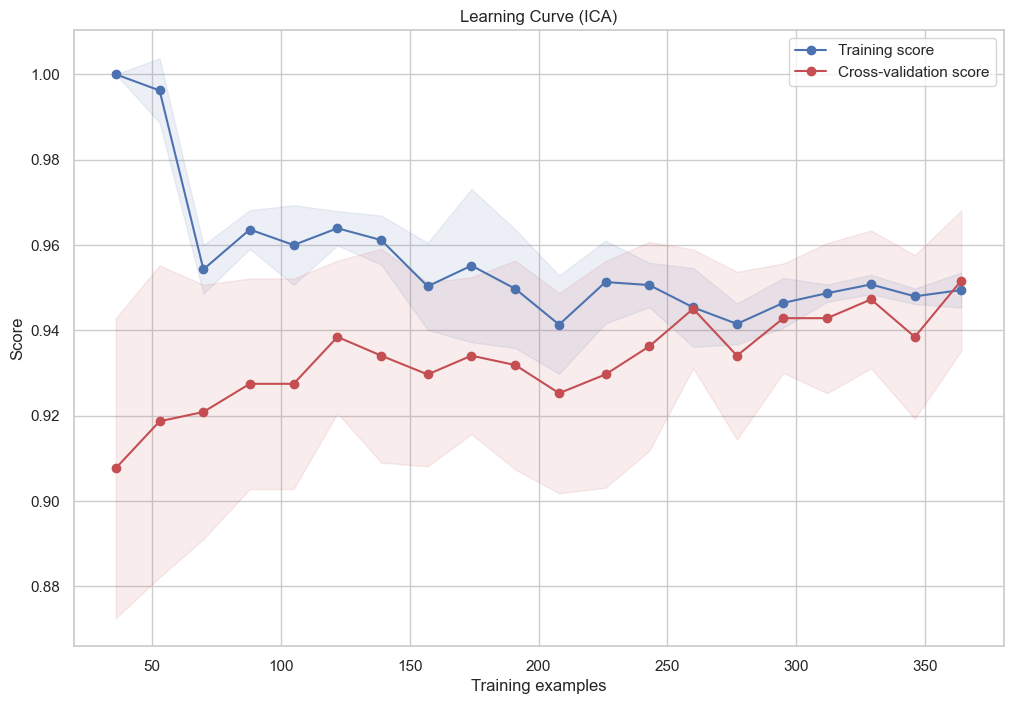

Training time (RP): 353.13 seconds
Best parameters (RP): {'activation': 'logistic', 'alpha': 0.01, 'hidden_layer_sizes': np.int64(34), 'learning_rate': 'invscaling', 'learning_rate_init': 0.01, 'solver': 'adam'}
Train accuracy (RP): 0.7780
Test accuracy (RP): 0.7632
Precision (RP): 0.7861
Recall (RP): 0.7632
F1 Score (RP): 0.7402
ROC AUC Score (RP): 0.6998


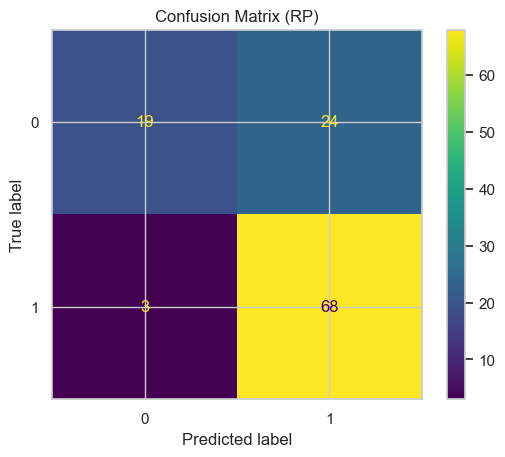

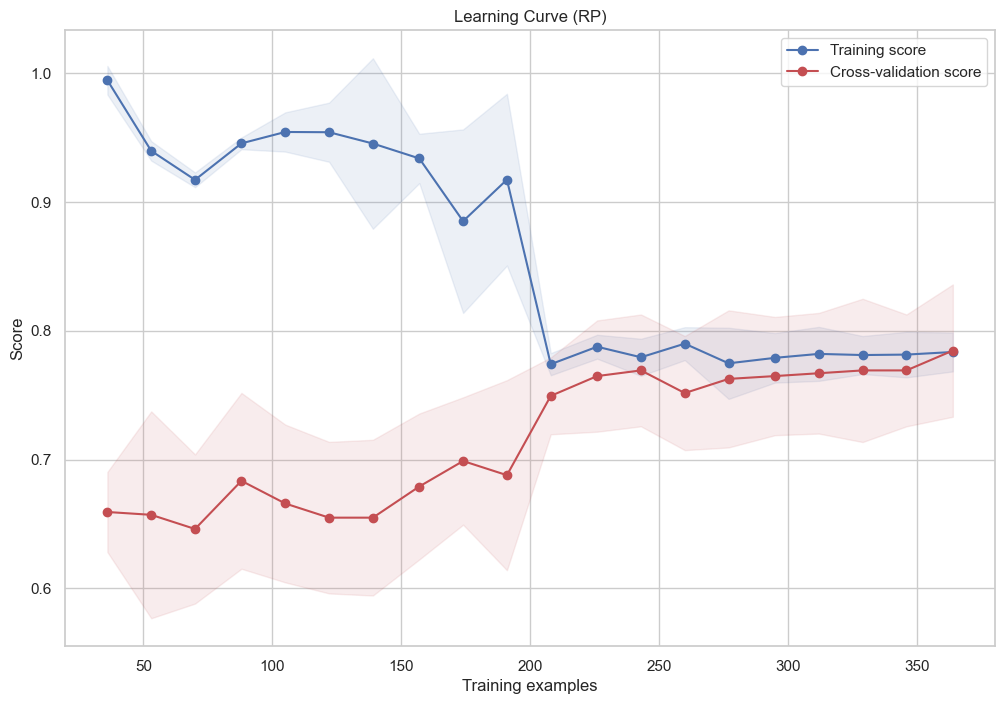

In [12]:
# %%
# Evaluate on original data
best_nn_original, train_score_original, test_score_original, training_time_original, precision_original, recall_original, f1_original, roc_auc_original = fit_and_evaluate(
    X_train, X_test, y_train, y_test, "Original"
)

# Evaluate on PCA data
best_nn_pca, train_score_pca, test_score_pca, training_time_pca, precision_pca, recall_pca, f1_pca, roc_auc_pca = fit_and_evaluate(
    X_train_pca, X_test_pca, y_train, y_test, "PCA"
)

# Evaluate on ICA data
best_nn_ica, train_score_ica, test_score_ica, training_time_ica, precision_ica, recall_ica, f1_ica, roc_auc_ica = fit_and_evaluate(
    X_train_ica, X_test_ica, y_train, y_test, "ICA"
)

# Evaluate on RP data
best_nn_rp, train_score_rp, test_score_rp, training_time_rp, precision_rp, recall_rp, f1_rp, roc_auc_rp = fit_and_evaluate(
    X_train_rp, X_test_rp, y_train, y_test, "RP"
)


In [13]:
# %%
# Compile results into a DataFrame
results = {
    "Method": ["Original", "PCA", "ICA", "RP"],
    "Train Accuracy": [
        train_score_original,
        train_score_pca,
        train_score_ica,
        train_score_rp,
    ],
    "Test Accuracy": [
        test_score_original,
        test_score_pca,
        test_score_ica,
        test_score_rp,
    ],
    "Training Time (s)": [
        training_time_original,
        training_time_pca,
        training_time_ica,
        training_time_rp,
    ],
    "Precision": [
        precision_original,
        precision_pca,
        precision_ica,
        precision_rp,
    ],
    "Recall": [
        recall_original,
        recall_pca,
        recall_ica,
        recall_rp,
    ],
    "F1 Score": [
        f1_original,
        f1_pca,
        f1_ica,
        f1_rp,
    ],
    "ROC AUC Score": [
        roc_auc_original,
        roc_auc_pca,
        roc_auc_ica,
        roc_auc_rp,
    ],
}

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_excel("./result/nn_performance_comparison.xlsx", index=False)

print("Results saved to './result/nn_performance_comparison.xlsx'")


     Method  Train Accuracy  Test Accuracy  Training Time (s)  Precision  \
0  Original        0.982418       0.991228         532.830547   0.991350   
1       PCA        0.947253       0.991228         381.397192   0.991350   
2       ICA        0.949451       0.991228         449.445940   0.991350   
3        RP        0.778022       0.763158         353.133431   0.786093   

     Recall  F1 Score  ROC AUC Score  
0  0.991228  0.991207       0.988372  
1  0.991228  0.991207       0.988372  
2  0.991228  0.991207       0.988372  
3  0.763158  0.740155       0.699803  


ModuleNotFoundError: No module named 'openpyxl'

In [ ]:
# %%
